In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

# Tutorial to Least Squares and Recursive Least Squares applied to parameter estimation.
## Tracking runner's performance

## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique commonly used to perform regression and/or parameter estimation. It achieves this by minimizing the sum of the squared differences between the observed data and predicted values by our model called residuals. The core idea is that smaller squared errors should mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero.

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\hat{\mathbf{x}}$ that best satisfies an overdetermined (More measurements than parameters) system of equations.

## Runner Performance Modeling

Imagine a scenario where a runner trains daily for a 1000m run. During training, he uses a sophisticated timer to keep a very accurate true time. He also wants to know his pace over the 1000m run during competition. However, on competition day, he will not have this sophisticated timer, so 3 coaches volunteered to record his times for that day. 1 coach will record times between distances (0 to 500) meters, another between distances (500 to 1000) meters, and the last at 1000 meters. (This is so that when practicing, we can pretend we are comparing against the coachs' times with the machine's to evaluate our soon to be proposed estimator)

We want to accurately estimate his time on competition day, knowing that the runner's strategy is to start slow in the first half and maintain a faster speed in the second half.

Each of our coaches will measure the **observed** time. This defines our model:

$$t_{observed,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j$$

Where:
*   $\theta_1$: The unknown model **parameter** representing the runner's pace (seconds per meter) in segment 1 (0-500m).
*   $\theta_2$: The unknown model **parameter** representing the runner's pace (seconds per meter) in segment 2 (500-1000m).
*   $d_{1,j} = \min(d_j, 500)$: The **known feature** being distance the runner traveled in segment 1 when passing coach $j$.
*   $d_{2,j} = \max(0, d_j - 500)$: The **known feature** being distance the runner traveled in segment 2 when passing coach $j$.
*   $\epsilon_j$: Coach $j$'s **measurement error** from timing imprecision and other unmodeled factors.

By estimating $\theta_1$ and $\theta_2$ from the three coaches' noisy time measurements, we can reconstruct the runner's true pace profile on competition day. Although, the given description is a **model mismatch** described best in the next section - the runner's strategy is not a linear function. But we approximate that because the distance is long, the runner's strategy is to keep a consistent pace and then instantaneously speed up on the later half. Then, our model design is linear with respect to the model parameters, so this problem can be formulated as a **linear system** for **parameter estimation** applicable for Least Squares.

### Potential LS reformulations (Beyond this tutorial's scope)

This tutorial focuses on recursive least squares (RLS). In practice, accurate model formulation is a key requirement for good estimation (The other, being good data collection and processing). This section briefly speaks to some ways a problem can be creatively reformulated to find LS solutions, serving as a roadmap to those with different problems:

*   **Modeling with nonlinear parameters:**
  \
  Our piecewise linear model already provides a simple approximation of the runner's acceleration through reparameterization of speed (m/s) instead of pace (s/m). If we designed our model with speed, our equation would be nonlinear.
  \
  $$t_{observed,j} = d_{1,j} / v_1 + d_{2,j} / v_2 + \epsilon_j$$
  \
  A reparameterization of $\theta = 1/v$ results in the same equation, but not without drawbacks (although, you will find in this tutorial we perform this transformation for better explainability). The error associated to the linear $\theta$ parameter would scale nonlinearly after transforming it back to $v$, which has serious consequences if low velocity values change quickly.
  \
  \
  A more accurate nonlinear model would be the **exponential pace model**:
  $$
  \theta(d) = \theta_{ss} + (\theta_0 - \theta_{ss})e^{-\theta_r d}
  $$
  where the runner smoothly transitions from initial pace $\theta_0$ to steady-state pace $\theta_{ss}$ with rate $\theta_r$. The cumulative time at distance $d_j$ is:
  $$
  t(d_j) = \theta_{ss} \cdot d_j + \frac{\theta_0 - \theta_{ss}}{\theta_r}(1 - e^{-\theta_r d_j})
  $$
  This model is **nonlinear** in the parameters due to $\theta_r$ appearing in both the exponent and denominator, requiring iterative nonlinear estimation methods.
  \
  \
  Alternatively, we can apply least squares to a **linearized differential equation** formulation. The exponential model satisfies:
  $$
  \theta'(d) = -\theta_r(\theta - \theta_{ss})
  $$
  \
  This reparameterization onto the pace rate provides a physics-based linear approach, though it introduces additional noise through differentiation.


*   **Modeling with nonlinear features:**
  \
  Our piecewise linear model provides a simple approximation of the runner's acceleration. However, a smoother and more realistic model could use **polynomial features** to capture continuous pace changes:
  $$
  t(d_j) = \theta_0 \cdot d_j + \theta_1 \cdot \frac{d_j^2}{2} + \theta_2 \cdot \frac{d_j^3}{3} + \epsilon_j
  $$
  where the pace function $\theta(d) = \theta_0 + \theta_1 d + \theta_2 d^2$ varies smoothly with distance. The features $d_j$, $d_j^2$, and $d_j^3$ are **nonlinear transformations** of the coach positions, but the model remains **linear in the parameters** $(\theta_0, \theta_1, \theta_2)$ and can be solved using standard least squares. This approach captures smooth acceleration and deceleration without requiring nonlinear optimization, providing a middle ground between the simplicity of piecewise linear models and the complexity of fully nonlinear models. However, a drawback to increasing this feature space is that models tend to overfit, and will usually require regularization.

*   **Estimating coach-specific timing bias**
  \
  Suppose the primary source of noise in the observed times comes from how each coach captures the split time at their position. We model this by introducing a coach-specific bias term:
  \
  $$
  t_{obs,j} = d_j^{(1)} \cdot \theta_1 + d_j^{(2)} \cdot \theta_2 + b_j + \epsilon_j
  $$
  \
  where $b_j$ captures the consistent timing bias associated with coach $j$ (e.g., one coach consistently starts their stopwatch early, another late). However, introducing a separate bias parameter for each coach often leads to an underdetermined system. With 4 coaches, we would have 5 parameters $$\theta_1, \theta_2, b_1, b_2, b_3$$ but only 3 measurements from a single run. This requires richer data collection, such as the runner performing multiple runs under different conditions, or having coaches measure multiple runners with known true times to calibrate their biases.

*   **Non-i.i.d. (independent and identically distributed) noise variance**
  \
  Standard least squares is the optimal estimator when measurement noise is Gaussian, independent, and identically distributed across all observations. However, we should expect the coaches to have different accuracies in their timing measurements:
  \
  -- Coach 1 might have faster reaction time (lower variance)
  \
  -- Coach 2 might be less experienced (higher variance)
  \
  When noise variances differ across coaches but are uncorrelated (heteroscedastic noise), **weighted least squares** is more appropriate.

*   **Regularized Least Squares (ridge or lasso)**
  \
  When using high-order polynomial features or many parameters, the system can overfit to noise. Regularization adds a penalty to the least squares objective function to shrink parameter estimates and improve generalization.


### Formulating a linear system (Ax=B)

To apply Least squares, we transform our runner timing model into the standard linear form:

For coach $j$ at position $d_j$:

$$
t_{obs,j} = d_{1,j} \cdot \theta_1 + d_{2,j} \cdot \theta_2 + \epsilon_j
$$

Where:
- $d_{1,j} = \min(d_j, 500)$ = distance in segment 1 (0-500m)
- $d_{2,j} = \max(0, d_j - 500)$ = distance in segment 2 (500-1000m)
- $\epsilon_j \sim N(0, \sigma)$ , where $\sigma$ would be in seconds

The above system of equations map to a matrix form:

$$
\vec{t}_{\mathrm{obs}} =
\mathbf{A}\vec{\theta}+\vec{\epsilon}
$$

Expanded:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$
\nFor example, with 3 Coaches at 250m, 750m, and 1000m:

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix} =
\begin{bmatrix}
250 & 0 \\
500 & 250 \\
500 & 500
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix} +
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\epsilon_3
\end{bmatrix}
$$

Determining this $\mathbf{A}$ matrix that contains the features from all measurements, known as the **Observation model** is a key component to LS formulation.

### Python imports
Below we start this project by including some python imports and creating our dataset by defining parameters and functions of our observation model and simulation.

This code is organized in object oriented design. In short, it is organized so that "objects" can be created, defined by the below "classes", which are used to mix and match and interact with other objects. This is an important framework for generalizabilty and to reduce redundancy, especially for something like LS. Apply the following templates as needed to create your own classes and objects for different problems.


#### Template: Data Generator Class

The below code describes a general data generator. I would say this is the most important and difficult piece to understand for Least Squares. For different problems, follow the template layout given in the below template: "DataGenerator" class. The runner class is an example data generator that uses this template to model **any equation** to be reparameterized into an Ax = b form. The runner class acts as a very simple example for this tutorial.

Below I give some brief explanation of the important portions of the class:

*   Class specific functions
    *   generate_measurement_features: Defines the features given problem
    *   compute_features: Translates the features to prepare to be applied into the A matrix. Reparameterizations or feature transformations happen here. This very may just pass outputs to the generate_A_matrix().
    *   compute_observation: Your equation to the model. This equation **can** be nonlinear, although do not expect good results without proper reparameterization handling.  
    *   update_parameters: If your parameters are dynamic, this is where you update them.
    *   init(): Defining how many parameters and what parameters will be applied.

*   Generally applicable to all problems functions
    *   generate_A_matrix: Given the feature value of each sensor, stores w.r.t the mth sensor and nth feature in the A matrix, for a given M x N, A matrix.
    *   generate_b_vector: Given measurements of each sensor, stores w.r.t that sensor.
    *   getters: any function with name "get" is for organizational purposes asked to get certain properties from an object.
    *   run_simulation: As described
    *   run_multiple_simulations: As described

At the end of the day, if you have your own data, you don't need this data generator. Your data must either already be from a linear parameter system. Then, **Measurements replace the b vector** and **features replace the A matrix**.

In [ ]:
# @title
import numpy as np
# ============================================
# Base Data Generator Class (General)
# ============================================
class DataGenerator:
    """
    General data generator for creating measurement data from a parametric model.
    Can handle any number of parameters and sensors.
    """

    def __init__(self, name, initial_params, noise_std=0.05, random_seed=None):
        """
        Initialize a general data generator.

        Parameters:
        -----------
        name : str
            Generator name/identifier
        initial_params : dict
            Dictionary of initial parameter values
            Example: {'theta_1': 0.1, 'theta_2': 0.09}
        noise_std : float
            Standard deviation of measurement noise
        random_seed : int, optional
            Random seed for reproducibility
        """
        self.name = name
        self.initial_params = initial_params.copy()
        self.current_params = initial_params.copy()
        self.noise_std = noise_std

        if random_seed is not None:
            self.rng = np.random.RandomState(random_seed)
        else:
            self.rng = np.random.RandomState()

        # Storage for simulation runs
        self.num_runs = 0
        self.data_cube = []  # List of (A, b, features) tuples
        self.params_history = []  # Track parameters over time
        self.measurement_features_history = []

    def generate_measurement_features(self, num_sensors):
        """
        Generate measurement features for sensors.
        Must be implemented by subclasses.

        Parameters:
        -----------
        num_sensors : int
            Number of sensors

        Returns:
        --------
        features : array
            Sensor features
        """
        raise NotImplementedError("Subclasses must implement generate_measurement_features()")

    def compute_features(self, features, params):
        """
        Compute feature vector for a given feature and parameters.
        Must be implemented by subclasses.

        Parameters:
        -----------
        features : float
            Measurement feature
        params : dict
            Model parameters

        Returns:
        --------
        features : array
            Feature vector for this feature
        """
        raise NotImplementedError("Subclasses must implement compute_features()")

    def compute_observation(self, features, params):
        """
        Compute true observation at a feature given parameters.
        Must be implemented by subclasses.

        Parameters:
        -----------
        features : float
            Measurement features
        params : dict
            Model parameters

        Returns:
        --------
        observation : float
            True observation value (before noise)
        """
        raise NotImplementedError("Subclasses must implement compute_observation()")

    def update_parameters(self, day):
        """
        Update parameters based on day.
        Can be overridden by subclasses for time-varying behavior.

        Parameters:
        -----------
        day : int
            Current day number (0-indexed)
        """
        # Base class: no change (constant parameters)
        pass

    def generate_A_matrix(self, features):
        """
        Generate design matrix A from measurement features.

        Parameters:
        -----------
        features : array of shape (num_sensors,)
            Measurement features

        Returns:
        --------
        A : array of shape (num_sensors, num_params)
            Design matrix
        """
        num_sensors = len(features)
        num_params = len(self.current_params)
        A = np.zeros((num_sensors, num_params))

        for i, pos in enumerate(features):
            features = self.compute_features(pos, self.current_params)
            A[i, :] = features

        return A

    def generate_b_vector(self, features, params, add_noise=True):
        """
        Generate observation vector b from features and parameters.

        Parameters:
        -----------
        features : array of shape (num_sensors,)
            Measurement features
        params : dict
            Model parameters
        add_noise : bool
            Whether to add measurement noise

        Returns:
        --------
        b : array of shape (num_sensors, 1)
            Observation vector
        """
        num_sensors = len(features)
        b = np.zeros((num_sensors, 1))

        for i, pos in enumerate(features):
            true_obs = self.compute_observation(pos, params)

            if add_noise:
                noise = self.rng.normal(0, self.noise_std)
                observed = true_obs + noise
            else:
                observed = true_obs

            b[i, 0] = observed

        return b

    def run_simulation(self, day, num_sensors, **kwargs):
        """
        Run one simulation and store A matrix and b vector.

        Parameters:
        -----------
        day : int
            Current day number (0-indexed)
        num_sensors : int
            Number of sensors for this run
        **kwargs : dict
            Additional arguments for feature generation

        Returns:
        --------
        A : array of shape (num_sensors, num_params)
            Design matrix
        b : array of shape (num_sensors, 1)
            Observation vector
        features : array of shape (num_sensors,)
            Measurement features
        """
        # Update parameters based on day
        self.update_parameters(day)

        # Generate measurement features
        features = self.generate_measurement_features(num_sensors, **kwargs)
        self.measurement_features_history.append(features)

        # Store parameters for this day
        self.params_history.append({
            'day': day,
            **self.current_params.copy()
        })

        # Generate A matrix and b vector
        A = self.generate_A_matrix(features)
        b = self.generate_b_vector(features, self.current_params)

        # Store this run's data
        self.data_cube.append((A, b, features))
        self.num_runs += 1

        return A, b, features

    def run_multiple_simulations(self, num_days, num_sensors, **kwargs):
        """
        Run multiple simulations over consecutive days.

        Parameters:
        -----------
        num_days : int
            Number of days to simulate
        num_sensors : int
            Number of sensors per run
        **kwargs : dict
            Additional arguments passed to run_simulation
        """
        for day in range(num_days):
            self.run_simulation(day, num_sensors, **kwargs)

    def get_simulation_data(self, day_idx):
        """
        Get A, b, and features for a specific day.

        Parameters:
        -----------
        day_idx : int
            Day index (0 to num_runs-1)

        Returns:
        --------
        A : array
            Design matrix
        b : array
            Observation vector
        features : array
            Measurement features
        """
        if day_idx >= self.num_runs:
            raise IndexError(f"Day {day_idx} not available. Only {self.num_runs} runs performed.")
        return self.data_cube[day_idx]

    def get_all_data(self):
        """
        Get all A and b matrices stacked.

        Returns:
        --------
        A_all : array
            Stacked design matrices
        b_all : array
            Stacked observation vectors
        """
        A_list = [A for A, b, pos in self.data_cube]
        b_list = [b for A, b, pos in self.data_cube]
        return np.vstack(A_list), np.vstack(b_list)

    def __repr__(self):
        param_str = ', '.join([f"{k}={v:.4f}" for k, v in self.current_params.items()])
        return f"DataGenerator(name='{self.name}', runs={self.num_runs}, {param_str})"

#### Runner class

The runner class as described before is an example of applying the template: data generator class.


In [ ]:
# @title

# ============================================
# Runner Class (Specific Implementation)
# ============================================

class Runner(DataGenerator):
    """
    Runner-specific data generator for piecewise linear pace model.
    - 2 parameters: theta_1 (pace in segment 1), theta_2 (pace in segment 2)
    - 3 sensors (coaches) positioned at specific locations
    - Distance range: 0-1000m with boundary at 500m
    - Pace measured in seconds per meter (s/m)
    """

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 noise_std=0.05, random_seed=None):
        """
        Initialize a runner with piecewise linear pace model.

        Parameters:
        -----------
        name : str
            Runner name/identifier
        initial_theta_1 : float
            Initial pace in segment 1 (0-500m) in s/m
        initial_theta_2 : float
            Initial pace in segment 2 (500-1000m) in s/m
        noise_std : float
            Standard deviation of measurement noise (seconds)
        random_seed : int, optional
            Random seed for reproducibility
        """
        initial_params = {
            'theta_1': initial_theta_1,
            'theta_2': initial_theta_2
        }
        super().__init__(name, initial_params, noise_std, random_seed)

        # Runner-specific attributes
        self.boundary = 500.0  # meters
        self.total_distance = 1000.0  # meters

    def generate_measurement_features(self, num_sensors=3, last_day=False):
        """
        Generate coach positions for a run.
        - Coach A: randomly between 0 and 500 meters
        - Coach B: randomly between 500 and 1000 meters
        - Coach C: always at 1000 meters
        On last day: fixed at [250, 750, 1000]

        Returns:
        --------
        features : array of shape (3,)
            Coach positions [coach_A, coach_B, coach_C]
        """
        if num_sensors != 3:
            raise ValueError("Runner requires exactly 3 coaches")

        if last_day:
            return np.array([250.0, 750.0, 1000.0])
        else:
            coach_A_pos = self.rng.uniform(0, self.boundary)
            coach_B_pos = self.rng.uniform(self.boundary, self.total_distance)
            coach_C_pos = self.total_distance
            return np.array([coach_A_pos, coach_B_pos, coach_C_pos])

    def compute_features(self, position, params):
        """
        Compute piecewise linear features for a position.

        Parameters:
        -----------
        position : float
            Distance along track (meters)
        params : dict
            Model parameters (not used, features depend only on position)

        Returns:
        --------
        features : array of shape (2,)
            [d1, d2] where:
            - d1 = distance in segment 1 (0-500m)
            - d2 = distance in segment 2 (500-1000m)
        """
        d1 = min(position, self.boundary)
        d2 = max(0, position - self.boundary)
        return np.array([d1, d2])

    def compute_observation(self, position, params):
        """
        Compute cumulative time at a position using piecewise pace model.

        Time = d1 * theta_1 + d2 * theta_2
        where pace is in seconds per meter.

        Parameters:
        -----------
        position : float
            Distance along track (meters)
        params : dict
            Model parameters with keys 'theta_1', 'theta_2'

        Returns:
        --------
        time : float
            Cumulative time at position (seconds)
        """
        theta_1 = params['theta_1']
        theta_2 = params['theta_2']

        features = self.compute_features(position, params)
        d1, d2 = features

        time = d1 * theta_1 + d2 * theta_2
        return time

    def run_simulation(self, day, last_day=False):
        return super().run_simulation(day, num_sensors=3, last_day=last_day)

    def run_multiple_simulations(self, num_days):
        for day in range(num_days):
            self.run_simulation(day, last_day=(day == num_days - 1))

    def __repr__(self):
        return (
            f"Runner(name='{self.name}', runs={self.num_runs}, "
            f"θ₁={self.current_params['theta_1']:.4f} s/m, "
            f"θ₂={self.current_params['theta_2']:.4f} s/m)")


# ============================================
# Specialized Runner Classes
# ============================================

class ConstantRunner(Runner):
    """Runner with constant pace throughout simulation."""

    def update_parameters(self, day):
        # No change - parameters stay constant
        pass


class ImprovingRunner(Runner):
    """Runner with gradually improving pace (pace decreases)."""

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 improvement_rate=0.0002, noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        improvement_rate : float
            Rate at which pace improves per day (pace decreases by this amount)
        """
        super().__init__(name, initial_theta_1, initial_theta_2, noise_std, random_seed)
        self.improvement_rate = improvement_rate

    def update_parameters(self, day):
        # Pace decreases (gets faster) over time
        self.current_params['theta_1'] = (
            self.initial_params['theta_1'] - self.improvement_rate * day
        )
        self.current_params['theta_2'] = (
            self.initial_params['theta_2'] - self.improvement_rate * day * 0.5
        )


class InjuredRunner(Runner):
    """Runner with sudden injury on a specific day, then gradual recovery."""

    def __init__(self, name, initial_theta_1, initial_theta_2,
                 injury_day=10, injury_severity=0.03, recovery_rate=0.0005,
                 noise_std=0.05, random_seed=None):
        """
        Parameters:
        -----------
        injury_day : int
            Day when injury occurs
        injury_severity : float
            How much pace increases (slows down) due to injury (s/m)
        recovery_rate : float
            Rate of recovery per day after injury (s/m per day)
        """
        super().__init__(name, initial_theta_1, initial_theta_2, noise_std, random_seed)
        self.injury_day = injury_day
        self.injury_severity = injury_severity
        self.recovery_rate = recovery_rate
        self.injury_impact = 0.0

    def update_parameters(self, day):
        if day == self.injury_day:
            # Injury occurs - sudden increase in pace (slower)
            self.injury_impact = self.injury_severity
        elif day > self.injury_day:
            # Gradual recovery - injury impact decreases
            self.injury_impact = max(0, self.injury_impact - self.recovery_rate)

        # Apply injury impact to parameters
        self.current_params['theta_1'] = self.initial_params['theta_1'] + self.injury_impact
        self.current_params['theta_2'] = self.initial_params['theta_2'] + self.injury_impact

#### Base Estimator Class

This is the most important class for use on data.

*   def estimator() - is where you apply your estimator equations
\
Examples are spread throughout this tutorial as we walk through how LS, BLS, EBLS, and RLS are applied.
*   def update() - is where you may update applying A and b matrices - for example, when accumulating A and b matrices for Batched LS.

In [ ]:
# @title
import numpy as np
class Estimator:
    """
    Base class for parameter estimators.
    Handles history tracking and common functionality.
    """
    def __init__(self, num_params=2):

        self.num_params = num_params

        # History tracking
        self.estimates_history = []
        self.prediction_error_history = []
        self.residual_history = []
        self.day_history = []

    def estimator(self,A,B):
        pass

    def update(self, A_new, b_new, day=None):
        """
        Estimate parameters for a single day using least squares.

        Parameters:
        -----------
        A_new : array of shape (num_coaches, 2)
            Design matrix
        b_new : array of shape (num_coaches, 1)
            Observation vector
        day : int, optional
            Day number for tracking
        """
        x_est = self.estimator(A_new, b_new)
        # Compute metrics
        prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)
        # Store results
        self._store_results(x_est, prediction_error, residuals, day)

    def _compute_prediction_error(self, A, b, x_est):
        """
        Compute prediction error and residuals.

        Parameters:
        -----------
        A : array
            Design matrix
        b : array
            Observation vector
        x_est : array
            Estimated parameters

        Returns:
        --------
        prediction_error : float
            Mean absolute prediction error
        residuals : array
            Residuals (b - A @ x_est)
        """
        b_predicted = A @ x_est
        residuals = b - b_predicted
        prediction_error = np.mean(np.abs(residuals))
        return prediction_error, residuals

    def _store_results(self, x_est, prediction_error, residuals, day=None):
        """
        Store estimation results in history.

        Parameters:
        -----------
        x_est : array
            Estimated parameters
        prediction_error : float
            Prediction error
        residuals : array
            Residuals
        day : int, optional
            Day number
        """
        self.estimates_history.append(x_est.copy())
        self.prediction_error_history.append(prediction_error)
        self.residual_history.append(residuals.copy())

        if day is not None:
            self.day_history.append(day)

    def _store_nan_results(self, b_shape, day=None):
        """
        Store NaN results when estimation fails.
        """
        self.estimates_history.append(np.full((self.num_params, 1), np.nan))
        self.prediction_error_history.append(np.nan)
        self.residual_history.append(np.full(b_shape, np.nan))

        if day is not None:
            self.day_history.append(day)

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_prediction_error_history(self):
        return np.array(self.prediction_error_history)

    def get_residual_history(self):
        return self.residual_history

#### Plotting Funcitonality

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

def plot_prediction_errors(runner, estimators_dict):
    """
    Plot prediction errors for one or more estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(errors))
        avg_error = np.nanmean(errors)

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        ax.plot(days, errors, marker=marker, linestyle='-', linewidth=2,
               markersize=3, alpha=0.7,
               label=f'{name} (avg: {avg_error:.4f} s)', color=color)

        if len(estimators_dict) == 1:
            ax.axhline(y=avg_error, color=color, linestyle='--', linewidth=2, alpha=0.5)

    ax.set_xlabel('Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Absolute Prediction Error (s)', fontsize=12, fontweight='bold')
    ax.set_title(f'{runner.name}: Prediction Errors', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_parameter_estimates(runner, estimators_dict):
    """
    Plot parameter estimates (theta_1 and theta_2) for one or more estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimators_dict : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    colors = ['#2E86AB', '#E63946', '#06A77D', '#9D4EDD', '#F77F00']
    markers = ['o', 's', '^', 'D', 'v']

    for idx, (name, (estimates, errors)) in enumerate(estimators_dict.items()):
        days = np.arange(len(estimates))

        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]

        # Plot theta_1
        axes[0].plot(days, estimates[:, 0], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=name, color=color)

        # Plot theta_2
        axes[1].plot(days, estimates[:, 1], marker=marker, linestyle='-',
                    linewidth=2, markersize=3, alpha=0.7,
                    label=name, color=color)

    axes[0].set_ylabel('θ₁ (0-500m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Parameter Estimates', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Day', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('θ₂ (500-1000m) - Pace (s/m)', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_pace_comparison(runner, estimates, day_idx=-1):
    """
    Plot pace (s/m) comparison for a single estimator on a specific day.
    Shows true piecewise model pace vs estimated piecewise model pace.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute paces
    pace_true = np.where(d < 500, theta_1_true, theta_2_true)
    pace_estimated = np.where(d < 500, theta_1_est, theta_2_est)
    pace_diff = pace_true - pace_estimated

    # Get coach positions
    _, _, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Pace comparison
    axes[0].plot(d, pace_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, pace_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach positions
    for i, pos in enumerate(positions):
        pace_at_pos = theta_1_true if pos < 500 else theta_2_true
        axes[0].scatter(pos, pace_at_pos, s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coaches' if i == 0 else '')

    axes[0].set_ylabel('Pace (s/m)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Pace Comparison (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Pace difference
    axes[1].plot(d, pace_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, pace_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Pace Difference (s/m)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)

    plt.tight_layout()
    plt.show()


def plot_velocity_comparison(runner, estimates, day_idx=-1):
    """
    Plot velocity comparison for a single estimator on a specific day.
    Shows true piecewise model vs estimated piecewise model.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute velocities (velocity = 1/pace)
    pace_true = np.where(d < 500, theta_1_true, theta_2_true)
    velocity_true = 1 / pace_true

    pace_estimated = np.where(d < 500, theta_1_est, theta_2_est)
    velocity_estimated = 1 / pace_estimated

    velocity_diff = velocity_true - velocity_estimated

    # Get coach positions
    _, _, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Velocity comparison
    axes[0].plot(d, velocity_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, velocity_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach positions
    for i, pos in enumerate(positions):
        pace_at_pos = theta_1_true if pos < 500 else theta_2_true
        vel_at_pos = 1 / pace_at_pos
        axes[0].scatter(pos, vel_at_pos, s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coaches' if i == 0 else '')

    axes[0].set_ylabel('Velocity (m/s)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Velocity Comparison (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='lower right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Velocity difference
    axes[1].plot(d, velocity_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, velocity_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Velocity Difference (m/s)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)

    plt.tight_layout()
    plt.show()


def plot_time_comparison(runner, estimates, day_idx=-1):
    """
    Plot cumulative time vs distance for a single estimator on a specific day.
    Shows true piecewise model vs estimated piecewise model.

    Parameters:
    -----------
    runner : Runner
        Runner object
    estimates : array of shape (num_days, 2)
        Estimated parameters
    day_idx : int
        Day index to visualize (-1 for last day)
    """
    if day_idx == -1:
        day_idx = len(estimates) - 1

    # Get estimated parameters
    theta_1_est = estimates[day_idx, 0]
    theta_2_est = estimates[day_idx, 1]

    # Get true parameters
    true_params = runner.params_history[day_idx]
    theta_1_true = true_params['theta_1']
    theta_2_true = true_params['theta_2']

    # Create distance array
    d = np.linspace(0, 1000, 1000)

    # Compute cumulative times - TRUE MODEL
    time_true = np.where(d < 500,
                         theta_1_true * d,  # Segment 1
                         theta_1_true * 500 + theta_2_true * (d - 500))  # Segment 2

    # Compute cumulative times - ESTIMATED MODEL
    time_estimated = np.where(d < 500,
                             theta_1_est * d,  # Segment 1
                             theta_1_est * 500 + theta_2_est * (d - 500))  # Segment 2

    time_diff = time_true - time_estimated

    # Get coach positions and observed times
    _, b_obs, positions = runner.get_simulation_data(day_idx)

    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top: Time comparison
    axes[0].plot(d, time_true, linewidth=2.5, color='#2E86AB',
                label='True (Piecewise)')
    axes[0].plot(d, time_estimated, linewidth=2.5, color='#E63946',
                linestyle='--', label='Estimated (Piecewise)')
    axes[0].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2,
                   label='Boundary (500m)')

    # Mark coach observations
    for i, pos in enumerate(positions):
        axes[0].scatter(pos, b_obs[i, 0], s=100, zorder=5,
                       edgecolors='black', linewidths=1.5, color='gold',
                       label='Coach Observations' if i == 0 else '')

    axes[0].set_ylabel('Cumulative Time (s)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{runner.name}: Time vs Distance (Day {day_idx + 1})',
                     fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='upper left')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1000)

    # Add parameter text
    param_text = (f'True: θ₁={theta_1_true:.4f}, θ₂={theta_2_true:.4f}\n'
                 f'Est:  θ₁={theta_1_est:.4f}, θ₂={theta_2_est:.4f}')
    axes[0].text(0.02, 0.98, param_text, transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Bottom: Time difference
    axes[1].plot(d, time_diff, linewidth=2.5, color='#9D4EDD')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    axes[1].fill_between(d, 0, time_diff, alpha=0.3, color='#9D4EDD')
    axes[1].axvline(x=500, color='orange', linestyle=':', alpha=0.5, linewidth=2)

    axes[1].set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Time Difference (s)', fontsize=12, fontweight='bold')
    axes[1].set_title('Estimation Error (True - Estimated)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 1000)

    plt.tight_layout()
    plt.show()

#### Simulation Functionality

Below code is what I use to control my simulation runs so that the same desired analysis or plots are not repeated, but intead just calls this function to do so.

Given a runner profile, a dictionary of estimators, number of simulation days, this will output the final estimates for each pace, the average error for estimating the finishing time, and analysis plots

In [ ]:
# @title
def run_estimation_analysis(runner, estimators_dict, num_days, plot_day_idx=-1, show_plots=True):
    """
    Run estimation analysis for a runner using multiple estimators.

    Parameters:
    -----------
    runner : Runner
        Runner object with completed runs
    estimators_dict : dict
        Dictionary mapping estimator names to estimator objects
        Example: {'LS': LeastSquares(), 'Batch LS': BatchedLeastSquares()}
    num_days : int
        Number of days to simulate
    plot_day_idx : int
        Day index for velocity/time/pace comparison plots (-1 for last day)
    show_plots : bool
        Whether to display plots

    Returns:
    --------
    results : dict
        Dictionary mapping estimator names to (estimates, errors) tuples
    """
    print(f"Running estimation analysis for {runner.name}...")
    print(f"Number of days: {num_days}")
    print(f"Estimators: {list(estimators_dict.keys())}")

    # Run all estimators day by day
    for day in range(num_days):
        A_curr, b_curr, _ = runner.get_simulation_data(day) # FIX IS HERE

        for name, estimator in estimators_dict.items():
            estimator.update(A_curr, b_curr, day=day)

    # Collect results
    results = {}
    for name, estimator in estimators_dict.items():
        estimates = estimator.get_estimate_history()
        errors = estimator.get_prediction_error_history()
        results[name] = (estimates, errors)

        # Print summary
        print(f"\n{name}:")
        print(f"  Final θ₁: {estimates[-1, 0]:.4f} s/m")
        print(f"  Final θ₂: {estimates[-1, 1]:.4f} s/m")
        print(f"  Avg Error: {np.mean(errors):.4f} s")

    # Generate plots if requested
    if show_plots:
        print("\nGenerating plots...")

        # Plot comparisons across all estimators
        plot_prediction_errors(runner, results)
        plot_parameter_estimates(runner, results)

        # Plot detailed analysis for each estimator
        for name, (estimates, errors) in results.items():
            print(f"  Plotting {name}...")
            plot_pace_comparison(runner, estimates, day_idx=plot_day_idx)
            plot_velocity_comparison(runner, estimates, day_idx=plot_day_idx)
            plot_time_comparison(runner, estimates, day_idx=plot_day_idx)

    return results

###Runners Initialization

We will keep track of 3 different runners. Where the runners keep two constant paces in s/m from 0 to 500m and 500m to 1000m. We will have the runners perform 100 runs, once per day. Runner A will keep same parameters. Runner B will **improve** ( the theta parameters increase slowly ). Runner C have an injury but will slowly recover. ( Theta parameters will decrease drastically on a particular day, but slowly increase.


I highly recommend going back to this portion here and experiment with the runners' functionality

In [ ]:
# @title
num_days = 100
noise_std = 0.15 # Human reaction timing offset maybe about 0.15 seconds std.

# Create three runners with different behaviors
runner_A = ConstantRunner(
    name="Runner A (Constant)",
    initial_theta_1=0.125,  # 0.125 s/m = 8 m/s
    initial_theta_2=0.100,  # 0.100 s/m = 10 m/s
    noise_std=noise_std,
    random_seed=42
)

runner_B = ImprovingRunner(
    name="Runner B (Improving)",
    initial_theta_1=0.140,
    initial_theta_2=0.110,
    noise_std=noise_std,
    improvement_rate=0.0002,  # Improves pace by 0.0002 s/m per day
    random_seed=43
)

runner_C = InjuredRunner(
    name="Runner C (Injured)",
    initial_theta_1=0.125,
    initial_theta_2=0.100,
    noise_std=noise_std,
    injury_day=10,
    injury_severity=0.04,  # Pace increases by 0.04 s/m (slows down)
    recovery_rate=0.0004,  # Recovers 0.0004 s/m per day
    random_seed=44
)

# Perform runs
print("Simulating 100 days of training...")
runner_A.run_multiple_simulations(num_days)
runner_B.run_multiple_simulations(num_days)
runner_C.run_multiple_simulations(num_days)

Simulating 100 days of training...


## Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's pace at each distance band for each day:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Least Squares Estimator
# ============================================

class LeastSQ(Estimator):
    """
    Daily Least Squares estimator.
    Estimates parameters independently for each day using standard LS.
    """

    def __init__(self):
        """Initialize the least squares estimator."""
        super().__init__(num_params=2)
    def estimator(self,A,B):
        # Solve least squares
        x_est = np.linalg.inv(A.T @ A) @ A.T @ B
        return x_est

###Run Simulation

Running estimation analysis for Runner A (Constant)...
Number of days: 100
Estimators: ['LS']

LS:
  Final θ₁: 0.1251 s/m
  Final θ₂: 0.0996 s/m
  Avg Error: 0.0508 s

Generating plots...


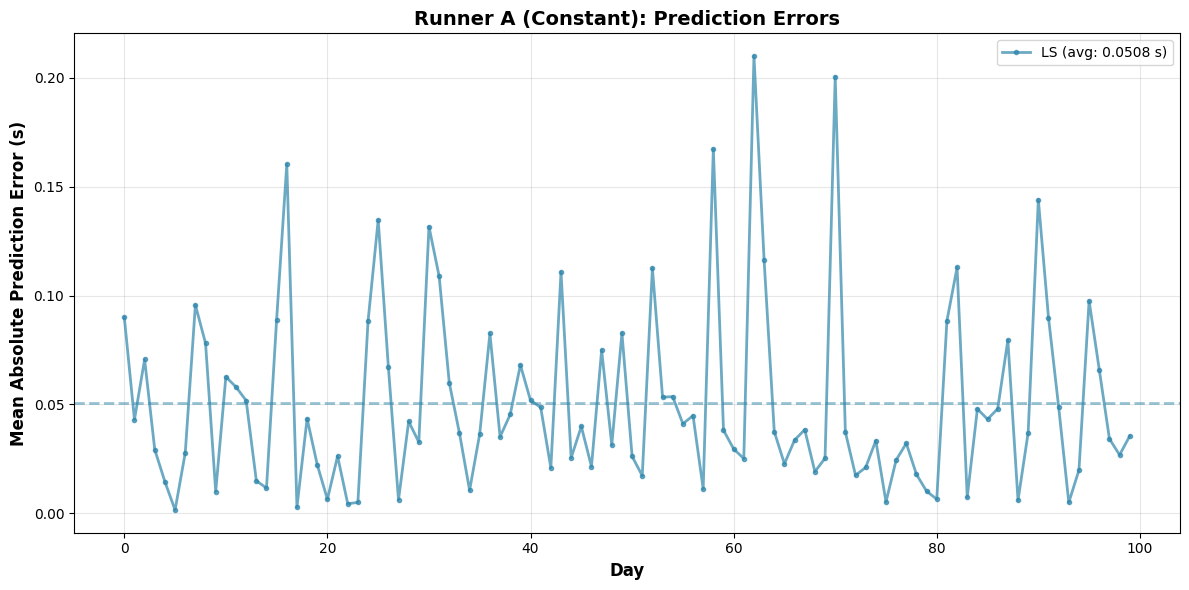

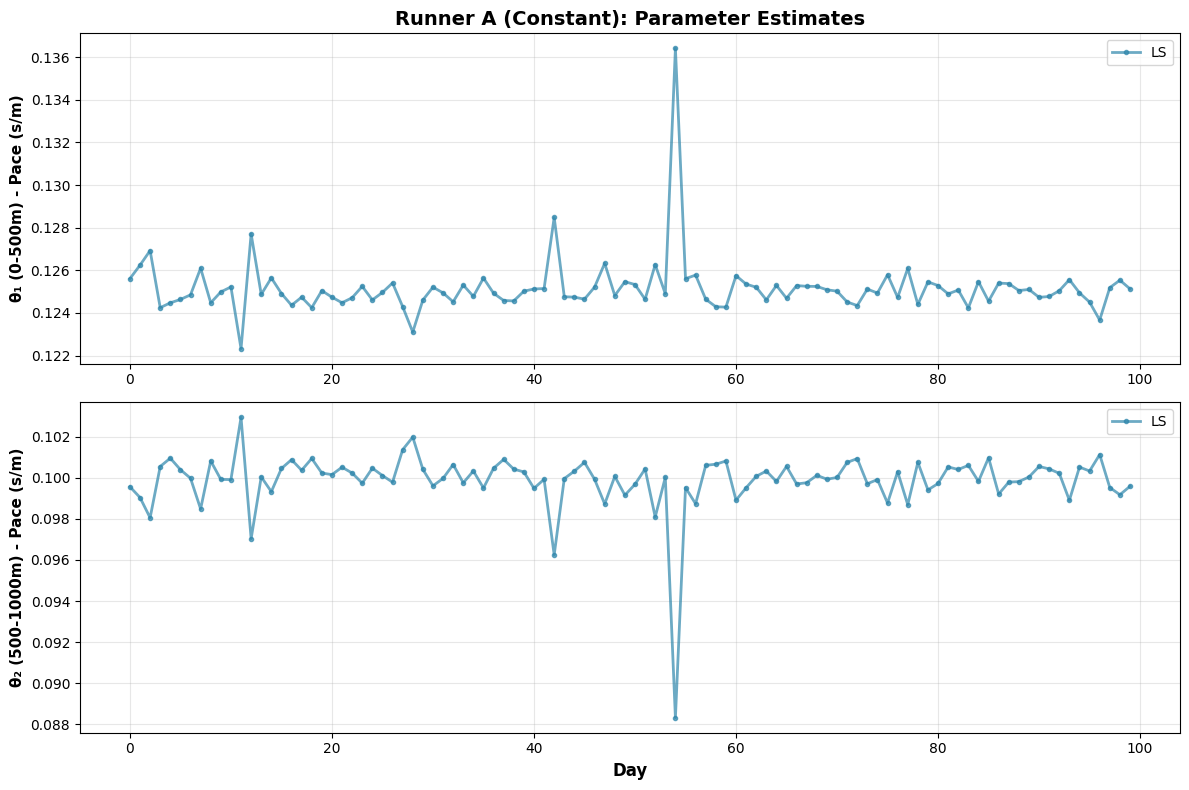

  Plotting LS...


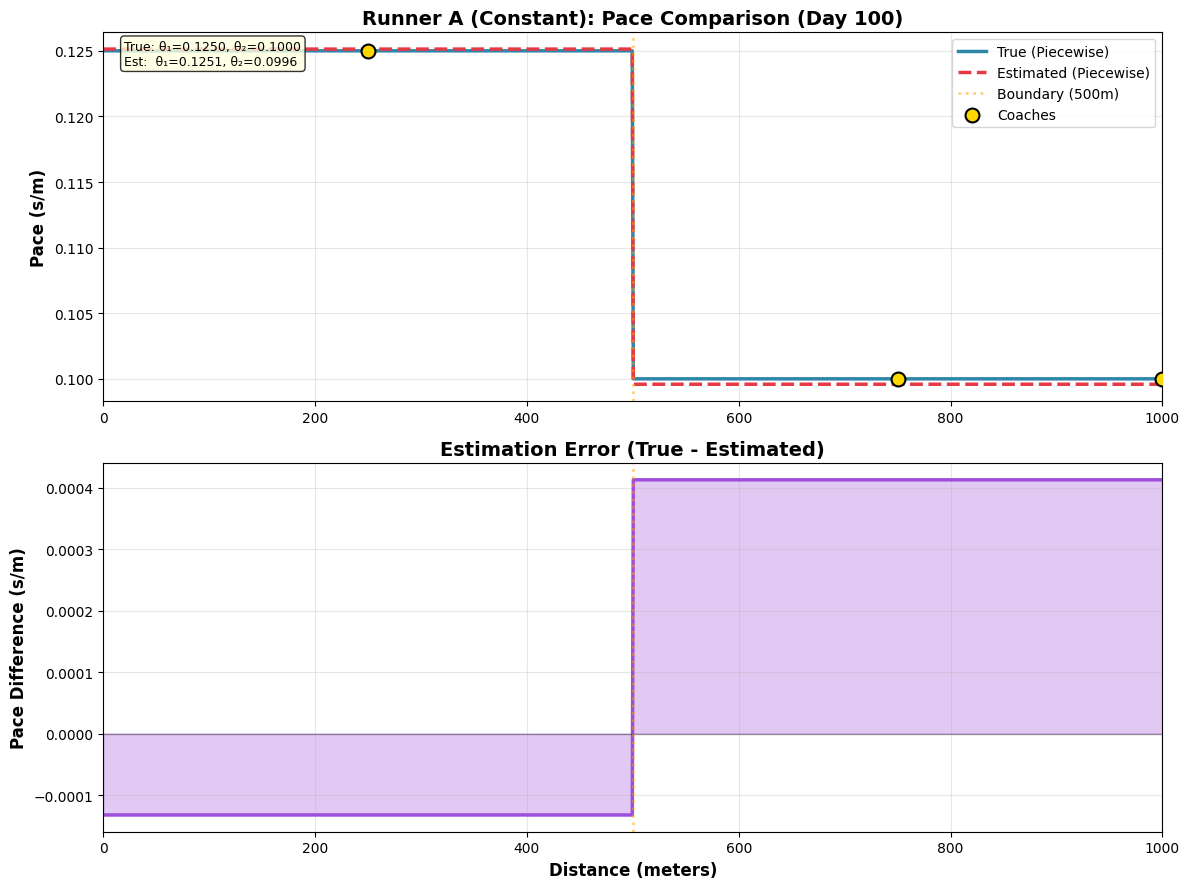

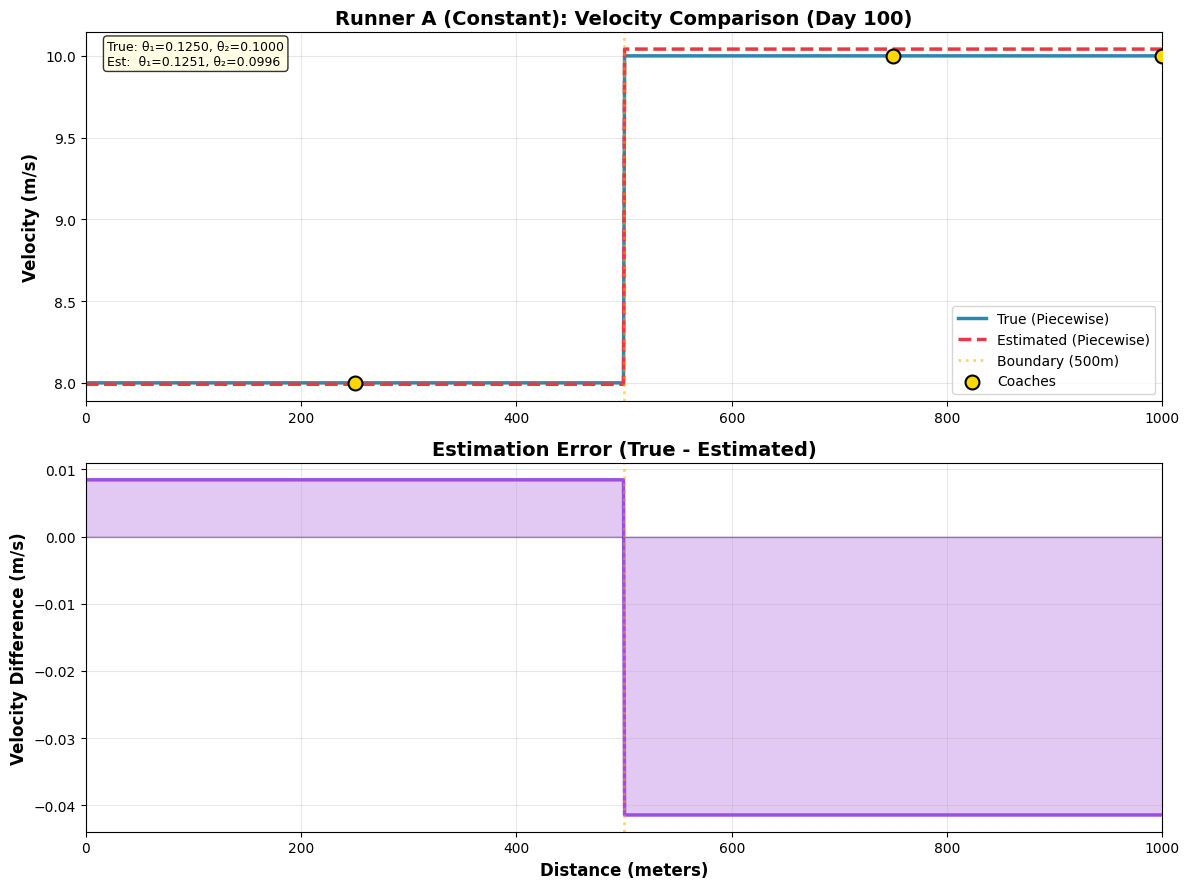

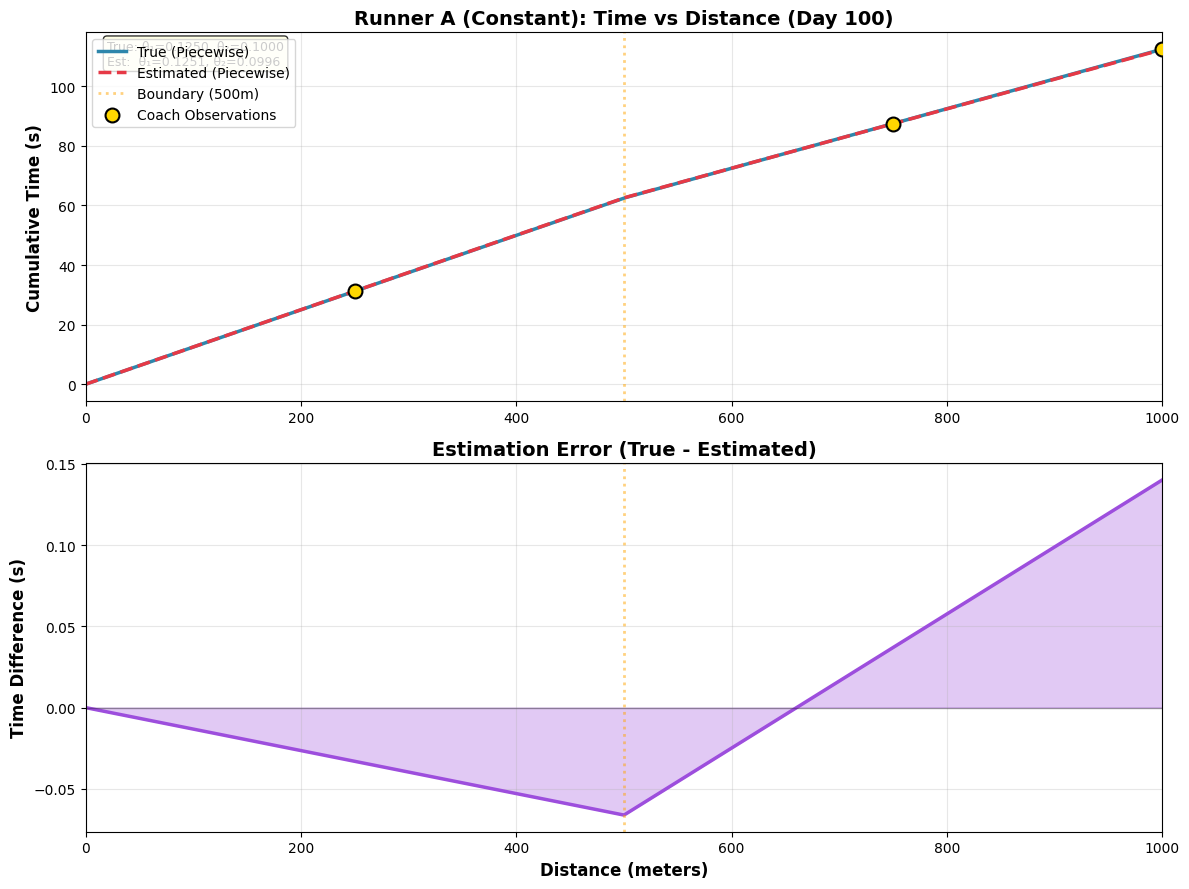

Running estimation analysis for Runner B (Improving)...
Number of days: 100
Estimators: ['LS']

LS:
  Final θ₁: 0.1209 s/m
  Final θ₂: 0.0995 s/m
  Avg Error: 0.0616 s
Running estimation analysis for Runner C (Injured)...
Number of days: 100
Estimators: ['LS']

LS:
  Final θ₁: 0.1301 s/m
  Final θ₂: 0.1036 s/m
  Avg Error: 0.0657 s


In [ ]:
# Setup
num_days = 100

# Define estimators to compare
estimators_A = {
    'LS': LeastSQ()
}
# Run analysis for Runner A
results_A = run_estimation_analysis(
    runner=runner_A,
    estimators_dict=estimators_A,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

# Run analysis for Runner B (create new estimators)
estimators_B = {
    'LS': LeastSQ()
}

results_B = run_estimation_analysis(
    runner=runner_B,
    estimators_dict=estimators_B,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=False
)

# Or run without plots and just get results
estimators_C = {
    'LS': LeastSQ()
}

results_C = run_estimation_analysis(
    runner=runner_C,
    estimators_dict=estimators_C,
    num_days=num_days,
    show_plots=False
)
# Access results later
estimates_ls_A, errors_ls_A = results_A['LS']
# Can plot specific things later
# plot_velocity_comparison(runner_A, estimates_ls_A, day_idx=50)

### Interpretation of Day 1 LS Results
# TODO: REFRACTOR THIS CELL

The Least Squares estimates for Day 1 show a reasonable estimation error, indicating that with more observations than parameters, the system is well-determined. For Day 1, we have `num_runs_per_day = 5` observations and are estimating `num_params = 2` parameters (1 baseline, 1 wind effect). This makes the system overdetermined, allowing for a stable LS solution. While the error is not zero, it's a significant improvement compared to an underdetermined system.

This outcome reinforces the necessity of having sufficient data to reliably estimate parameters, which is why we move to Batch Least Squares and Recursive Least Squares. These methods accumulate observations over time, providing a sufficiently rich dataset for stable and accurate parameter estimation.

It's clear this is making a better estimate from measurements, not actually using prior measurements to perform a best measurement for Day 100.

### KEY quesitons:

## Batch Least Squares for Runner Timing

#TODO: REFRACTOR THE PROSE
While the single-day LS provides an immediate estimate, it's often noisy and inaccurate due to limited data. What if we want to use *all* the past data to get a more robust estimate of the runner's baseline ability and wind effect?

This is where **Batch Least Squares** comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters (runner's baseline, wind effect) are relatively constant over the batch period.

### Mathematical Formulation

Suppose we collect observations over $K$ days. On each day $k$, we have $J$ coaches (in our case, $J=3$) measuring split times at different positions.

**For day $k$, we have a block of equations:**

$$
\begin{bmatrix}
t_{obs,1} \\
t_{obs,2} \\
t_{obs,3}
\end{bmatrix}_k
=
\begin{bmatrix}
d_{1,1} & d_{2,1} \\
d_{1,2} & d_{2,2} \\
d_{1,3} & d_{2,3}
\end{bmatrix}_k
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix}_k
+
\begin{bmatrix}
\epsilon_{1} \\
\epsilon_{2} \\
\epsilon_{3}
\end{bmatrix}_k
$$

Or more compactly: $\mathbf{t}_k = \mathbf{A}_k \boldsymbol{\theta} + \boldsymbol{\epsilon}_k$.

**Dimensions:**
- Each $\mathbf{t}_k$: $(3 \times 1)$ — 3 coaches' observations on day $k$
- Each $\mathbf{A}_k$: $(3 \times 2)$ — 3 coaches' position features on day $k$


**Optimization problem**

Our goal is to solve this optimization problem, minimizing the sum of squared residuals across all $K$ days:

$$
\hat{\boldsymbol{\theta}} = \underset{\boldsymbol{\theta}}{\operatorname{argmin}} \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$$


If we recognize a property that $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $.

$$\hat{\boldsymbol{\theta}} = \underset{\boldsymbol{\theta}}{\operatorname{argmin}} \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2
$$

Where:
$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{t}_1 \\ \mathbf{t}_2 \\ \vdots \\ \mathbf{t}_K \end{bmatrix} $$


**Stacking all $K$ days together for Simulation:**

$$
\begin{bmatrix}
\mathbf{t}_1 \\
\mathbf{t}_2 \\
\vdots \\
\mathbf{t}_K
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{A}_1 \\
\mathbf{A}_2 \\
\vdots \\
\mathbf{A}_K
\end{bmatrix}
\begin{bmatrix}
\theta_1 \\
\theta_2
\end{bmatrix}
+
\begin{bmatrix}
\boldsymbol{\epsilon}_1 \\
\boldsymbol{\epsilon}_2 \\
\vdots \\
\boldsymbol{\epsilon}_K
\end{bmatrix}
$$

**Dimensions:**
- Stacked system: $(3K \times 1) = (3K \times 2) \cdot (2 \times 1)$

**Key insight:** The coach positions change randomly each day, so each $\mathbf{A}_k$ is different. This is important for simulation - while in data science this is , for estimation ???

# TODO: SPECIFY WHY THIS KEY INSIGHT IS IMPORTANT




### Creating a Batch LS

# TODO: 2-3 sentences on code below how it inherits from LS and all it needs is accumulation

In [ ]:
class BatchedLeastSQ(LeastSQ):
    """
    Batched Least Squares estimator.
    Accumulates data across days and applies least squares to accumulated data.
    """
    def __init__(self):
        super().__init__()

        # Accumulated data
        self._A_accum = None
        self._b_accum = None

    def update(self, A_new, b_new, day=None):
        """
        Accumulate new data and estimate parameters using batched least squares.
        """

        # Accumulate data
        if self._A_accum is None:
            self._A_accum = A_new.copy()
            self._b_accum = b_new.copy()
        else:
            self._A_accum = np.vstack([self._A_accum, A_new])
            self._b_accum = np.vstack([self._b_accum, b_new])

        # Use parent's estimator method on accumulated data
        x_est = self.estimator(self._A_accum, self._b_accum)

        # Compute metrics on current data
        prediction_error, residuals = self._compute_prediction_error(A_new, b_new, x_est)

        # Store results
        self._store_results(x_est, prediction_error, residuals, day)

### Run Simulation

Running estimation analysis for Runner A (Constant)...
Number of days: 100
Estimators: ['LS', 'Batch LS']

LS:
  Final θ₁: 0.1251 s/m
  Final θ₂: 0.0996 s/m
  Avg Error: 0.0508 s

Batch LS:
  Final θ₁: 0.1250 s/m
  Final θ₂: 0.1001 s/m
  Avg Error: 0.1118 s

Generating plots...


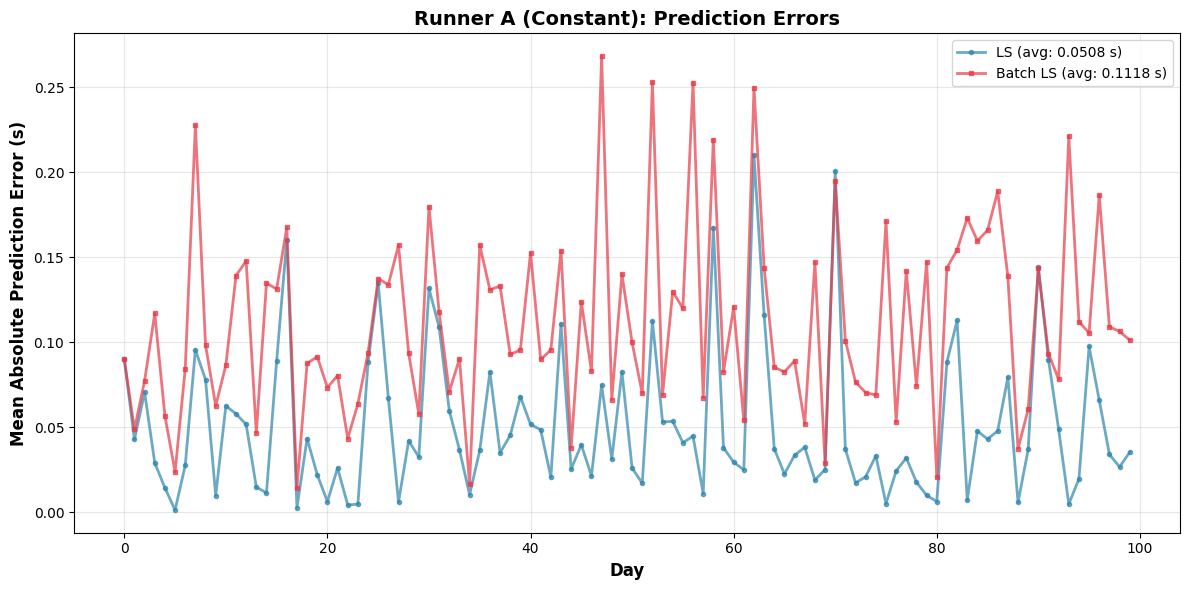

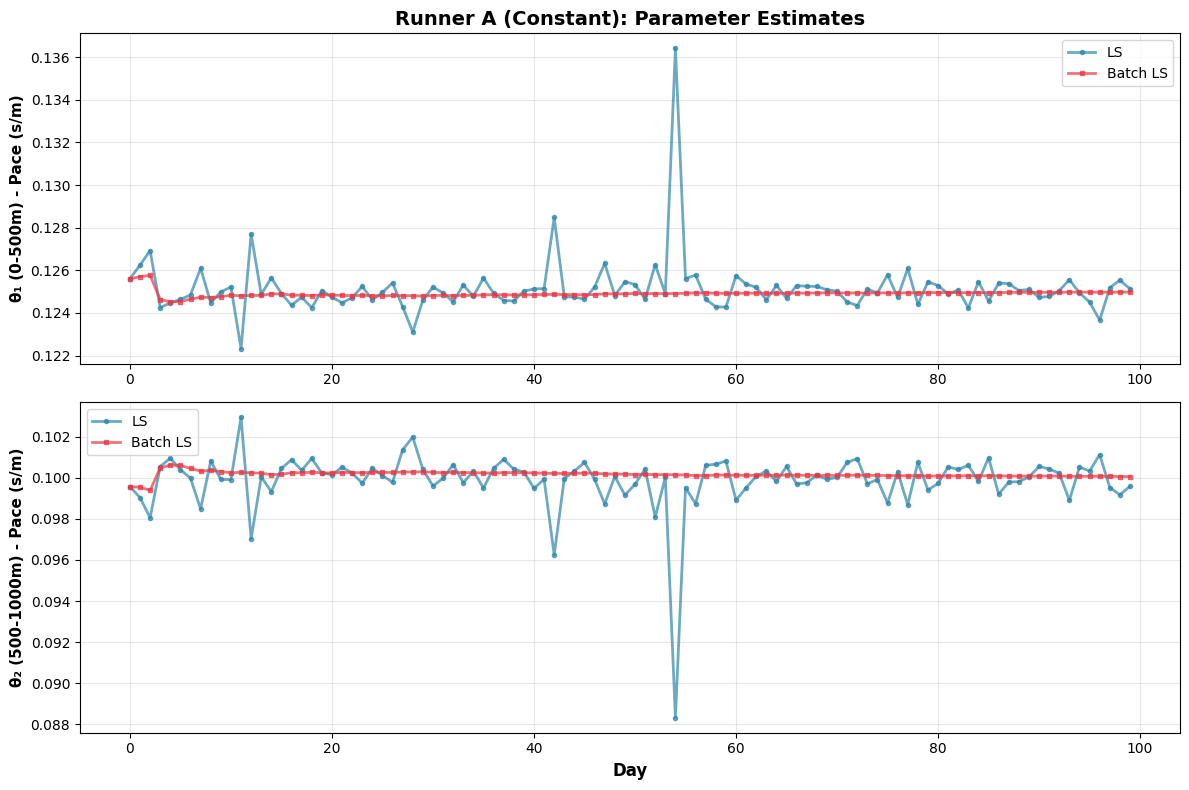

  Plotting LS...


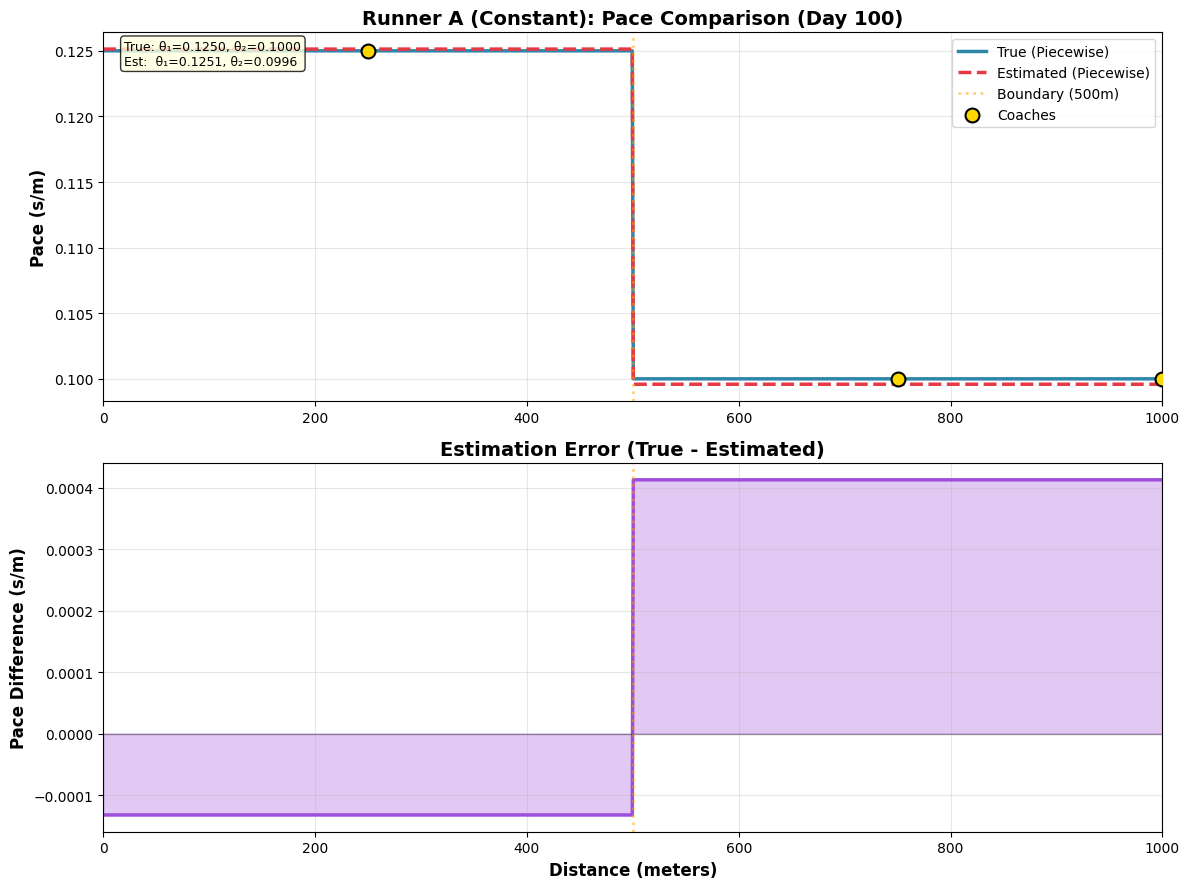

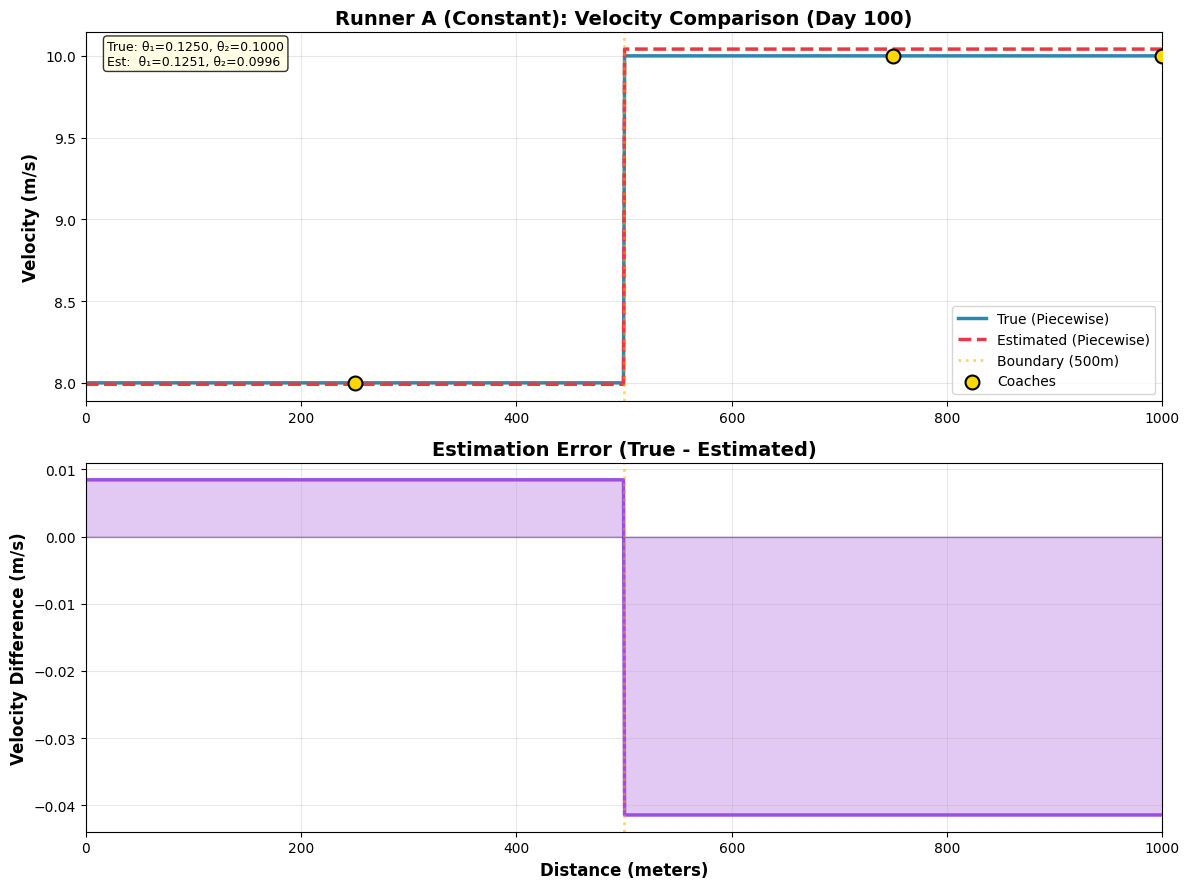

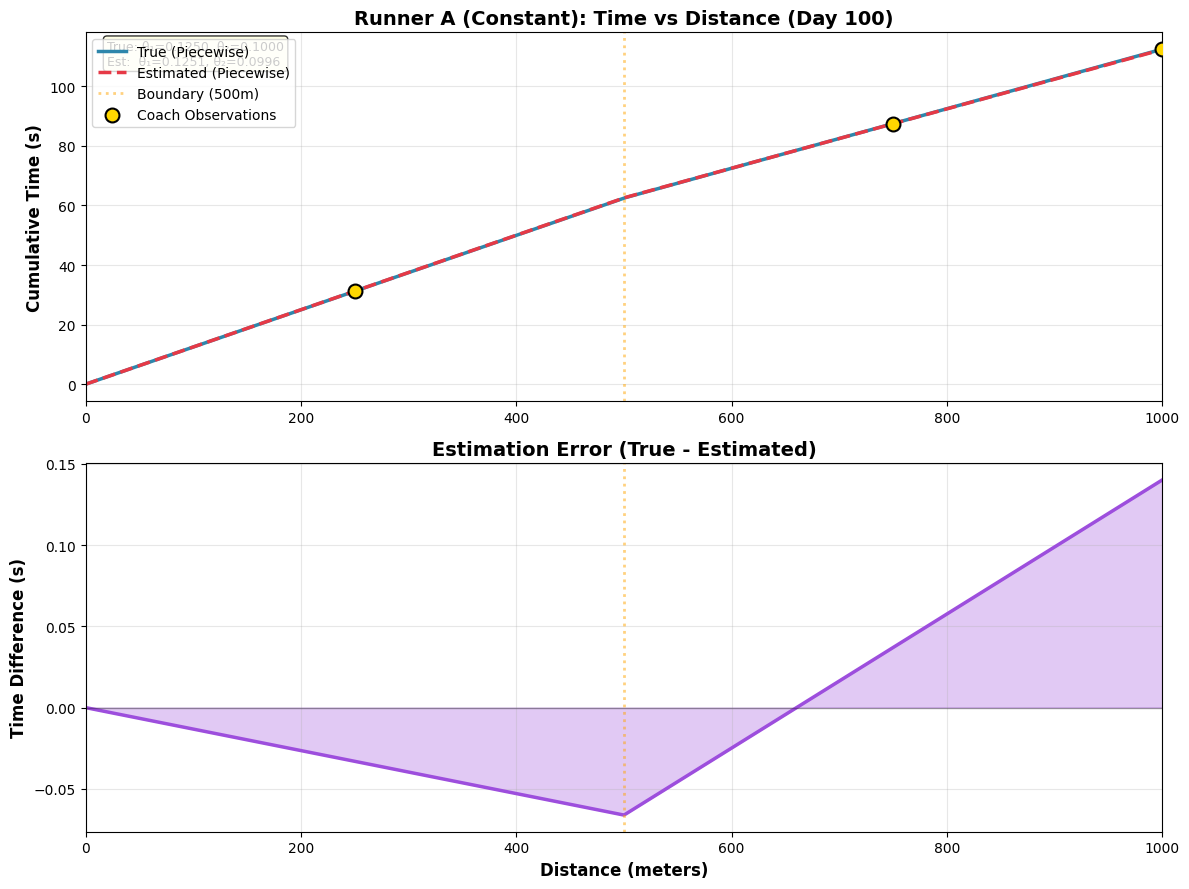

  Plotting Batch LS...


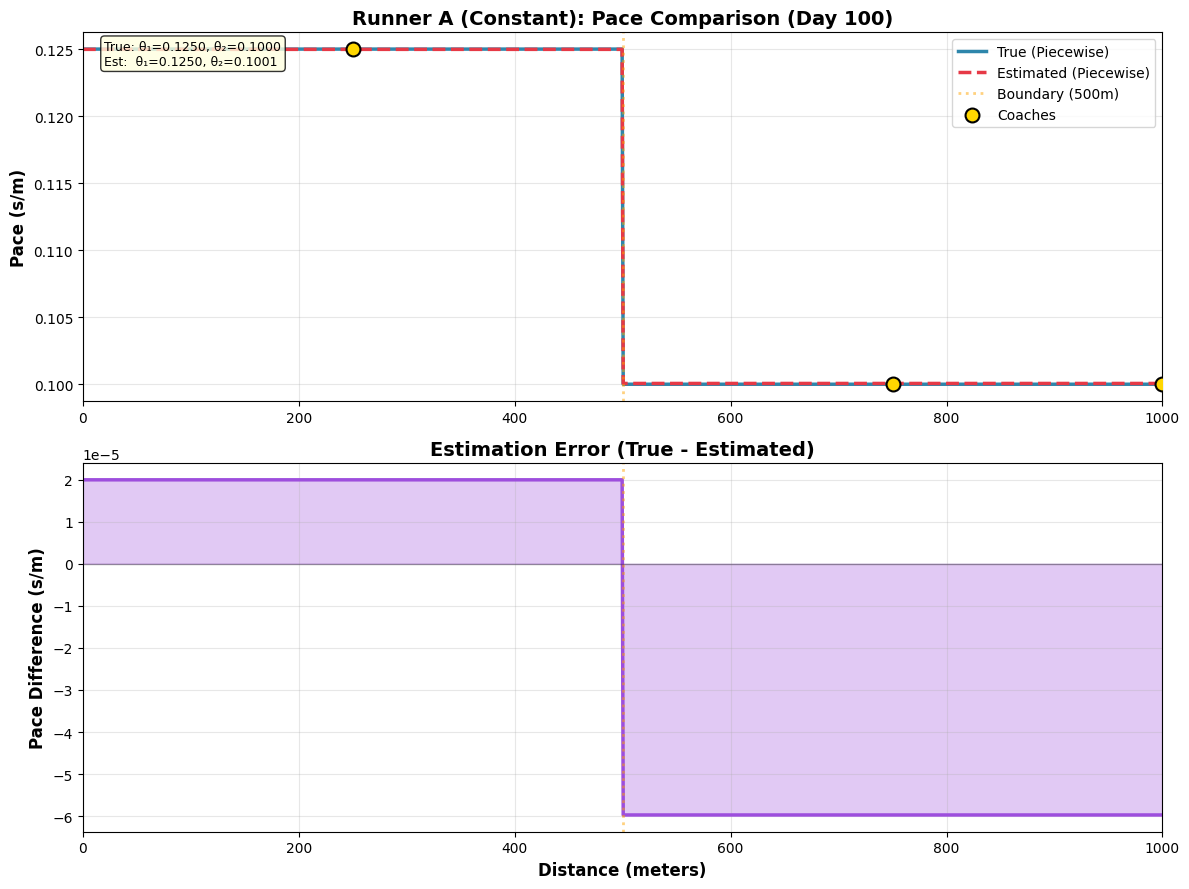

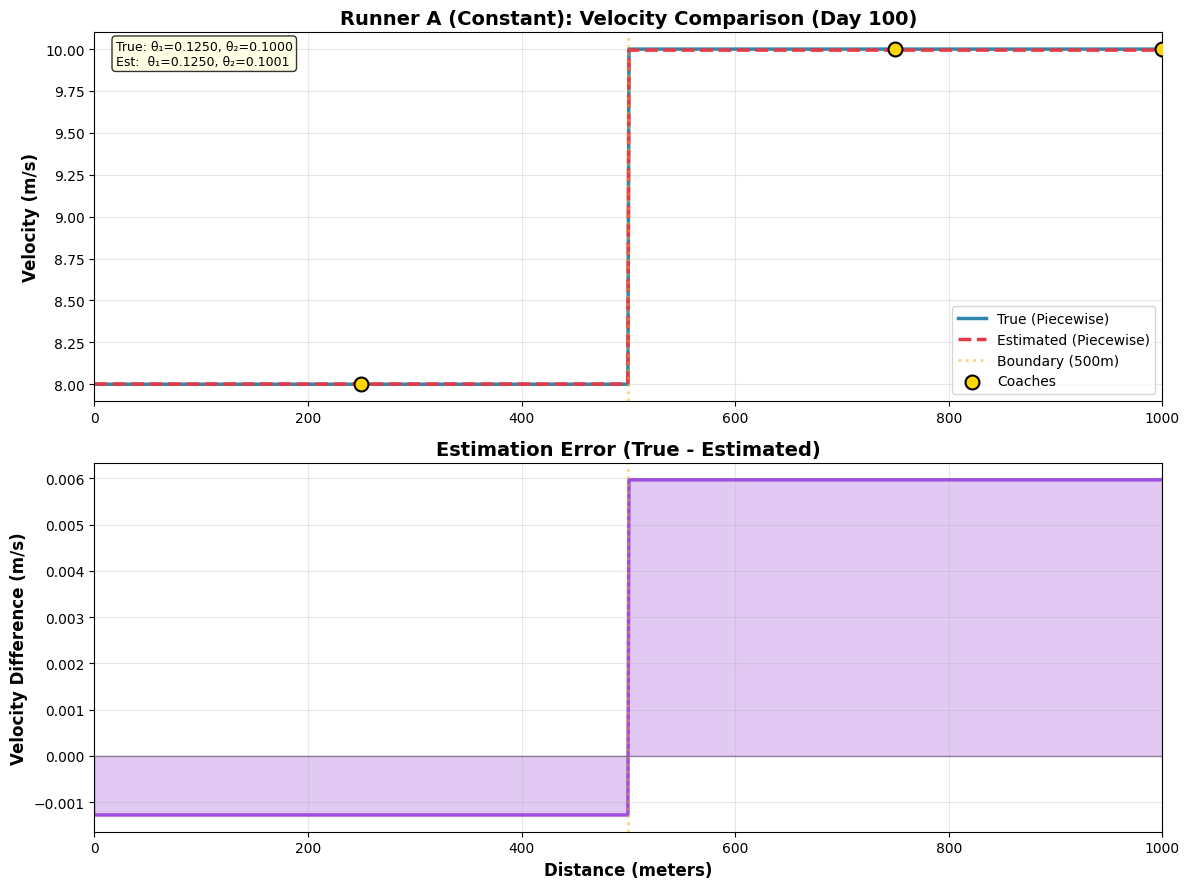

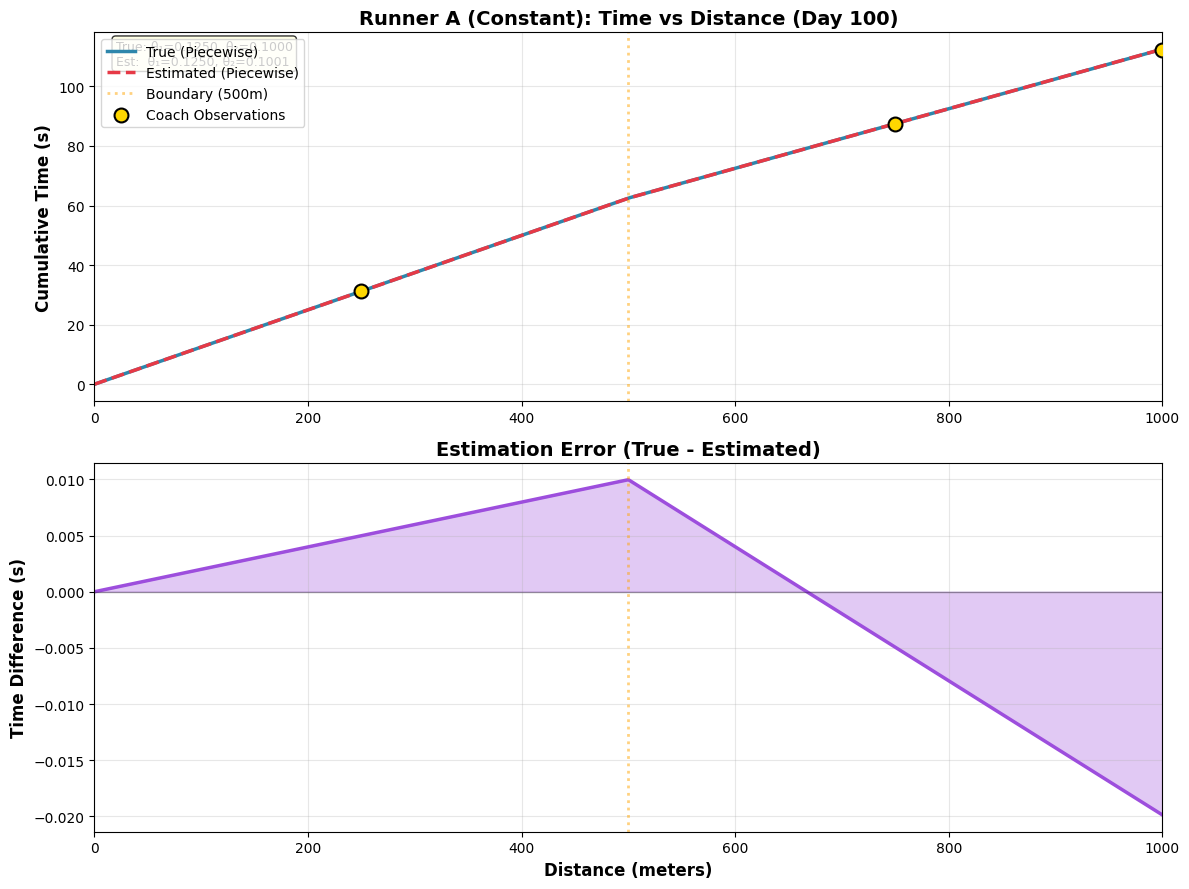

Running estimation analysis for Runner B (Improving)...
Number of days: 100
Estimators: ['LS', 'Batch LS']

LS:
  Final θ₁: 0.1209 s/m
  Final θ₂: 0.0995 s/m
  Avg Error: 0.0616 s

Batch LS:
  Final θ₁: 0.1299 s/m
  Final θ₂: 0.1053 s/m
  Avg Error: 2.7185 s


In [ ]:
# Setup
num_days = 100

# Define estimators to compare
estimators_A = {
    'LS': LeastSQ(),
    'Batch LS': BatchedLeastSQ()
}
# Run analysis for Runner A
results_A = run_estimation_analysis(
    runner=runner_A,
    estimators_dict=estimators_A,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=True)

# Run analysis for Runner B (create new estimators)
estimators_B = {
    'LS': LeastSQ(),
    'Batch LS': BatchedLeastSQ()
}

results_B = run_estimation_analysis(
    runner=runner_B,
    estimators_dict=estimators_B,
    num_days=num_days,
    plot_day_idx=-1,
    show_plots=False
)

# Access results later
estimates_ls_A, errors_ls_A = results_A['LS']
# Can plot specific things later
# plot_velocity_comparison(runner_A, estimates_ls_A, day_idx=50)

## Exponential Weighted Least Squares (EWLS)

In our runner estimators, we've assumed that the runner does not improve as he practices, that is the pace parameters would stay the same. However, this would not be true - the runner likely will be improving as time goes on (Runner B), or he may have an injury and his pace may dramatically drop (Runner C). One way to "track and update" would be to slide a window of days and calculate LS.

However, between the number of days inside this window, the are evaluated the same. If the runners do improve slowly, exponentially weighting these estimates so that the more recent collected data has more impact could be a better strategy. This is called the **exponentially weighted least squares (EWLS)**.

### EWLS Formulation

A Weighted LS (WLS) objective function minimizes the sum of squared weighted residuals similar to that as BLS, except with the added term $w$, for $k$th run:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} w_k (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 $$

Or, in matrix form, it minimizes:

$$ \hat{\mathbf{x}}_{WLS} = \underset{\mathbf{x}}{\operatorname{argmin}} (\mathbf{A} \mathbf{x} - \mathbf{b})_{stack}^T \mathbf{W} (\mathbf{A} \mathbf{x} - \mathbf{b})_{stack} $$

Where $\mathbf{W}$ is a diagonal matrix containing the weights $w_k$ on its diagonal, where each diagonal element corresponds to the weight of the respective $k$th stacked observation:

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_K) = \begin{bmatrix}
w_{K-1} & 0 & \dots & 0 \\
0 & w_{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & w_{0}
\end{bmatrix} $$

However, for EWLS ...

$$ \mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_K) = \begin{bmatrix}
\lambda^{K-1} & 0 & \dots & 0 \\
0 & \lambda^{K-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \lambda^{0}
\end{bmatrix} $$

## Exponential Weighted Least Squares (EWLS)

Building upon the concept of Weighted Least Squares, **Exponential Weighted Least Squares (EWLS)** extends the idea of weighting to account for the temporal relevance of data. In scenarios where parameters might drift or change over time (e.g., the runner's baseline performance improving or changing due to training), it's often desirable to give more importance to recent observations and gradually 'forget' older data.

EWLS achieves this by assigning exponentially decaying weights to older observations. This is conceptually similar to the forgetting factor introduced in Recursive Least Squares (RLS). The weight matrix $\mathbf{W}$ in EWLS is constructed such that measurements taken more recently receive higher weights than older measurements. This makes EWLS a more adaptive method than standard Batch WLS, allowing the estimates to track slowly varying parameters.

If we have a forgetting factor $\lambda$ (where $0 < \lambda \le 1$), the weights might be applied such that the most recent observation has a weight of $1$, the previous observation a weight of $\lambda$, the one before that $\lambda^2$, and so on. This effectively places greater emphasis on current data. This dynamic weighting mechanism is a crucial bridge to understanding how RLS operates, especially when incorporating a forgetting factor, as RLS inherently provides this recency weighting in its recursive updates.

In [ ]:
num_days_to_simulate = 100

# Create estimators
batch_ls_estimator = BatchedLeastSQ()

print("Running batch LS estimator for Runner A...")

# Run estimator day by day for Runner A
for day in range(num_days_to_simulate):
    A_curr, b_curr, _ = runner_A.get_run_data(day);
    batch_ls_estimator.update(A_curr, b_curr, day=day)

# Get results
estimates_batch = batch_ls_estimator.get_estimate_history()
errors_batch = batch_ls_estimator.get_prediction_error_history()

print("Batch LS estimation complete. Results stored in `estimates_batch` and `errors_batch`.")

In [ ]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

## Recursive Least Squares (RLS)

As we saw with Batch Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the inverse of the $\mathbf{A}^T\mathbf{A}$ matrix (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

### Recursive Least Squares Math

Let's start by recalling the Batch LS solution written in terms of $\mathbf{S}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{A}_i$ and $\mathbf{q}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{b}_i$:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \mathbf{P}_K \mathbf{q}_K $$

Where $\mathbf{P}_K = \mathbf{S}_K^{-1}$.

When a new observation arrives at step $K+1$, consisting of $\mathbf{A}_{K+1}$ (a single row vector) and $\mathbf{b}_{K+1}$ (a single scalar), we can update $\mathbf{S}$ and $\mathbf{q}$ recursively:

$$ \mathbf{S}_{K+1} = \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

The challenge is to efficiently compute the new inverse $\mathbf{P}_{K+1} = \mathbf{S}_{K+1}^{-1}$ without re-inverting the entire matrix. This is where the **Woodbury Matrix Identity** (also known as the Sherman–Morrison–Woodbury formula) becomes incredibly useful:

For matrices $\mathbf{P}$, $\mathbf{H}$, and $\mathbf{R}$ where $\mathbf{P}^{-1}$ and $(\mathbf{R} + \mathbf{H} \mathbf{P} \mathbf{H}^T)^{-1}$ exist:

$$ (\mathbf{P} + \mathbf{H}^T \mathbf{R}^{-1} \mathbf{H})^{-1} = \mathbf{P}^{-1} - \mathbf{P}^{-1} \mathbf{H}^T (\mathbf{R} + \mathbf{H} \mathbf{P}^{-1} \mathbf{H}^T)^{-1} \mathbf{H} \mathbf{P}^{-1} $$

Applying this identity to find $\mathbf{P}_{K+1} = (\mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1}$, let:

*   $\mathbf{P} = \mathbf{S}_K^{-1} = \mathbf{P}_K$
*   $\mathbf{H}^T = \mathbf{A}_{K+1}^T$ (so $\mathbf{H} = \mathbf{A}_{K+1}$)
*   $\mathbf{R}^{-1} = \mathbf{I}$ (a $1 \times 1$ identity matrix, as $\mathbf{A}_{K+1}^T \mathbf{A}_{K+1}$ is a rank-1 update; essentially the scalar 1, representing the weighting of the new measurement contribution)

Then the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K $$

And finally, the update for the estimate $\hat{\mathbf{x}}_{K+1}$ is:

$$ \hat{\mathbf{x}}_{K+1} = \hat{\mathbf{x}}_K + \mathbf{K}_{K+1} (\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K) $$

Where $\mathbf{K}_{K+1}$ is the Kalman gain-like term for RLS:

$$ \mathbf{K}_{K+1} = \mathbf{P}_{K+1} \mathbf{A}_{K+1}^T = \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

This set of equations allows us to update our estimates iteratively, day by day, or run by run, without re-processing all historical data. The term $(\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K)$ represents the residual or innovation—the difference between the actual new measurement and what the current model predicted.

### Incorporating Forgetting Factor (Weighted RLS)

Often, in real-world scenarios, the true underlying parameters might not be constant but instead change slowly over time. For example, our runner's baseline performance might improve. To account for this, RLS can be extended with a **forgetting factor** ($\lambda$, where $0 < \lambda \le 1$).

The forgetting factor gives more weight to recent data and gradually 'forgets' older data. This is achieved by modifying the updates for $\mathbf{S}$ and $\mathbf{q}$:

$$ \mathbf{S}_{K+1} = \lambda \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \lambda \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

And consequently, the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = (\lambda \mathbf{P}_K^{-1} + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1} $$

Which, using the Woodbury identity, can be rewritten as:

$$ \mathbf{P}_{K+1} = \frac{1}{\lambda} \left( \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T \left(\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T\right)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K \right) $$

And the gain term:

$$ \mathbf{K}_{K+1} = \mathbf{P}_K \mathbf{A}_{K+1}^T (\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

If $\lambda=1$, this is standard RLS. If $\lambda < 1$, older data has less influence. A common practice is to initialize $\mathbf{P}_0$ with a large value (e.g., $10^3 \cdot \mathbf{I}$) to reflect high initial uncertainty in the parameters.

### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.

In [ ]:
class RecursiveLeastSQ:
    def __init__(self, lambda_=1.0, P0_diag=1e3):
        self.lambda_ = lambda_
        self.num_params = 2
        self.P_k = P0_diag * np.eye(self.num_params)
        self.x_k = np.zeros((self.num_params, 1))
        self.estimates_history = []
        self.error_history = []

    def update(self, A_new, b_new, true_params):
        for i in range(A_new.shape[0]):
            A_i = A_new[i:i+1, :]
            b_i = b_new[i:i+1, :]
            denom = self.lambda_ + A_i @ self.P_k @ A_i.T
            K = (self.P_k @ A_i.T) / denom
            self.x_k = self.x_k + K @ (b_i - A_i @ self.x_k)
            self.P_k = (self.P_k - K @ A_i @ self.P_k) / self.lambda_
        self.estimates_history.append(self.x_k.copy())
        self.error_history.append(np.linalg.norm(self.x_k - true_params))

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)

In [ ]:
rls_estimator = RecursiveLeastSQ(lambda_=0.98, P0_diag=1e3)

# Run RLS day by day using the runner data
for day in range(num_days_to_simulate):
    A_curr, b_curr, _ = runner_A.get_run_data(day)
    rls_estimator.update(A_curr, b_curr, true_params_vec)

rls_estimates = rls_estimator.get_estimate_history()
rls_errors = rls_estimator.get_error_history()

print(f"Final RLS Estimates for {runner_A.name} (lambda=0.98):")
print(f"theta_1: {rls_estimates[-1, 0]:.4f}, theta_2: {rls_estimates[-1, 1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(rls_errors, color='red')
plt.title('RLS Error over Time')
plt.xlabel('Day')
plt.ylabel('Error')
plt.grid(True)
plt.show()

### Comparing Batch LS and RLS Convergence

Let's plot the errors from both Batch LS and RLS on the same graph to visualize their convergence and performance.

We would expect both methods to converge to similar estimates for constant parameters as the amount of data increases, assuming an appropriate forgetting factor (like $\lambda=1$ or close to 1 for RLS). RLS might show a slightly different convergence path due to its sequential updating nature and the impact of the forgetting factor and initial conditions.

In [ ]:
# Plotting Batch LS and RLS error convergence together
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Using the numpy arrays generated from the estimators in cells f7c37491 and 87KR0fli9M4-
plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()

### Equivalence between RLS and Batch LS

By setting $P_0$ to a very high value and $\lambda=1$, RLS becomes mathematically equivalent to the Batch Least Squares solution. A small $P_0$ acts like Ridge Regression (L2 regularization), while a very large $P_0$ removes that bias.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Standard Batch LS (no forgetting)
batch_pure = BatchedLeastSQ(lambda_=1.0)
# 2. RLS with massive P0 (effectively no regularization) and no forgetting
rls_pure = RecursiveLeastSQ(lambda_=1.0, P0_diag=1e12)

for day in range(num_days_to_simulate):
    A, b, _ = runner_A.get_run_data(day)
    batch_pure.update_batch(A, b, true_params_vec)
    rls_pure.update(A, b, true_params_vec)

# Comparison Plot
plt.figure(figsize=(10, 5))
plt.plot(batch_pure.get_error_history(), label='Batch LS', linewidth=4, alpha=0.3, color='blue')
plt.plot(rls_pure.get_error_history(), label='RLS (P0=1e12)', linestyle='--', color='red')
plt.title('Convergence of RLS to Batch LS with Large P0')
plt.xlabel('Day')
plt.ylabel('Estimation Error')
plt.legend()
plt.grid(True)
plt.show()

# Numerical check of the final estimates
print(f"Final Batch Estimate: {batch_pure.get_estimate_history()[-1]}")
print(f"Final RLS Estimate:   {rls_pure.get_estimate_history()[-1]}")
print(f"Difference: {np.linalg.norm(batch_pure.get_estimate_history()[-1] - rls_pure.get_estimate_history()[-1])}")

## Tracking Time-Varying Performance

Now we will apply our estimators to **Runner B (Improving)** and **Runner C (Injured)**. Because their physical parameters change daily, we must compare our estimates against the specific ground truth for each day.

We will use a forgetting factor $\lambda = 0.95$ for the estimators to allow them to 'forget' old, stale data and adapt to the runner's new pace.

In [ ]:
def run_tracking_simulation(runner, lambda_val=0.95):
    """Helper to run both estimators and return histories with dynamic true params."""
    batch_sim = BatchedLeastSQ(lambda_=lambda_val)
    rls_sim = RecursiveLeastSQ(lambda_=lambda_val, P0_diag=1e3)

    for day in range(runner.num_runs):
        A, b, _ = runner.get_run_data(day)
        # Get the true parameters for THIS specific day from the runner's history
        tp = runner.true_params_history[day]
        # We are estimating theta_1 and theta_2 (piecewise linear)
        # For simplicity, we approximate the true piecewise parameters from the exponential model history
        true_vec = np.array([[tp['theta_0']], [tp['theta_inf']]])

        batch_sim.update_batch(A, b, true_vec)
        rls_sim.update(A, b, true_vec)

    return batch_sim, rls_sim

# Simulate Runner B (Improving)
batch_B, rls_B = run_tracking_simulation(runner_B, lambda_val=0.95)

# Simulate Runner C (Injured)
batch_C, rls_C = run_tracking_simulation(runner_C, lambda_val=0.95)

print(f"Simulation complete for {runner_B.name} and {runner_C.name}")

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot Runner B
axs[0].plot(batch_B.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[0].plot(rls_B.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[0].set_title(f'Tracking Error: {runner_B.name}')
axs[0].set_ylabel('Estimation Error')
axs[0].legend()
axs[0].grid(True)

# Plot Runner C
axs[1].plot(batch_C.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[1].plot(rls_C.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[1].set_title(f'Tracking Error: {runner_C.name}')
axs[1].set_xlabel('Day')
axs[1].set_ylabel('Estimation Error')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Tracking Time-Varying Performance

Now we will apply our estimators to **Runner B (Improving)** and **Runner C (Injured)**. Because their physical parameters change daily, we must compare our estimates against the specific ground truth for each day.

We will use a forgetting factor $\lambda = 0.95$ for the estimators to allow them to 'forget' old, stale data and adapt to the runner's new pace.

In [ ]:
def run_tracking_simulation(runner, lambda_val=0.95):
    """Helper to run both estimators and return histories with dynamic true params."""
    batch_sim = BatchedLeastSQ(lambda_=lambda_val)
    rls_sim = RecursiveLeastSQ(lambda_=lambda_val, P0_diag=1e3)

    for day in range(runner.num_runs):
        A, b, _ = runner.get_run_data(day)
        # Get the true parameters for THIS specific day
        tp = runner.true_params_history[day]
        true_vec = np.array([[tp['theta_0']], [tp['theta_inf']]])

        batch_sim.update_batch(A, b, true_vec)
        rls_sim.update(A, b, true_vec)

    return batch_sim, rls_sim

# Simulate Runner B (Improving)
batch_B, rls_B = run_tracking_simulation(runner_B, lambda_val=0.95)

# Simulate Runner C (Injured)
batch_C, rls_C = run_tracking_simulation(runner_C, lambda_val=0.95)

print(f"Simulation complete for {runner_B.name} and {runner_C.name}")

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot Runner B
axs[0].plot(batch_B.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[0].plot(rls_B.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[0].set_title(f'Tracking Error: {runner_B.name}')
axs[0].set_ylabel('Estimation Error')
axs[0].legend()
axs[0].grid(True)

# Plot Runner C
axs[1].plot(batch_C.get_error_history(), label='Batch LS (lambda=0.95)', color='blue', alpha=0.7)
axs[1].plot(rls_C.get_error_history(), label='RLS (lambda=0.95)', color='red', linestyle='--')
axs[1].set_title(f'Tracking Error: {runner_C.name}')
axs[1].set_xlabel('Day')
axs[1].set_ylabel('Estimation Error')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()